#!pip install "numpy<1.25" scipy #This version from ChatGPT
import pandas
#!pip install pysimplegui

import PySimpleGUI as sg
import numpy as np

#!pip install openpyxl

import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import pyabf 
import sys
import scipy
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import statistics
# import matplotx
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
import openpyxl

In [3]:
#pip install "numpy<1.25" pandas scipy matplotlib PySimpleGUI pyabf openpyxl

In [1]:
import numpy as np
import pandas
import scipy
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import PySimpleGUI as sg
import pyabf
import statistics  # встроенный модуль, не требует установки
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

PySimpleGUI is now located on a private PyPI server.  Please add to your pip command: -i https://PySimpleGUI.net/install

The version you just installed should uninstalled:
   python -m pip uninstall PySimpleGUI
   python -m pip cache purge

Then install the latest from the private server:
python -m pip install --upgrade --extra-index-url https://PySimpleGUI.net/install PySimpleGUI

You can also force a reinstall using this command and it'll install the latest regardless of what you have installed currently
python -m pip install --force-reinstall --extra-index-url https://PySimpleGUI.net/install PySimpleGUI

Use python3 command if you're running on the Mac or Linux


In [2]:
#!pip install ipywidgets

import ipywidgets as widgets
from IPython.display import display
widgets.IntSlider()


# GUI to choose file
tres = 0
my_file = False
while True:
    event, values = sg.Window('Get filename example', [[sg.Text('Filename')], [sg.Input(), sg.FileBrowse()], [sg.OK(), sg.Cancel()] ]).read(close=True)
    if event == 'Cancel':
        break
    try:
        my_file = pyabf.ABF(values[0])
        break
    except:
        print('Incorrect file format')

#pip install ipyfilechooser
jupyter nbextension enable --py widgetsnbextension

from ipyfilechooser import FileChooser
from IPython.display import display
import os

# Получаем домашнюю папку пользователя
home_dir = os.path.expanduser('~')

# Создаем виджет выбора файла, начиная с домашней папки
fc = FileChooser(home_dir)
fc.title = 'Выберите ABF файл для анализа'
fc.filter_pattern = '*.abf'  # показываем только abf файлы

display(fc)

import tkinter as tk
from tkinter import filedialog


# Создаём скрытое главное окно Tkinter
root = tk.Tk()
root.withdraw()  # Скрываем главное окно

# Открываем диалог выбора файла
file_path = filedialog.askopenfilename(
    title="Выберите ABF файл",
    filetypes=[("ABF files", "*.abf")]
)

# Проверяем и загружаем файл
if file_path:
    print("Файл выбран:", file_path)
    my_file = pyabf.ABF(file_path)
else:
    print("Файл не выбран.")

In [2]:
file_path = input("Введите путь к файлу: ")
my_file = pyabf.ABF(file_path)


Введите путь к файлу: F:\Elizaveta Vylekzhanina (from April 2024)\2025\2025_05_19\2025_05_19_0038.abf


if fc.selected is not None:
    try:
        my_file = pyabf.ABF(fc.selected)
        print(f'Файл {fc.selected} успешно загружен')
    except Exception as e:
        print('Ошибка при открытии файла:', e)
else:
    print('Файл не выбран')

In [108]:
#help(pyabf)

In [109]:
#print(my_file)
#dir(my_file)

In [3]:
channels_num = int(my_file.channelCount)
sample_rate = int(my_file.dataRate)

print(channels_num, sample_rate)

4 20000


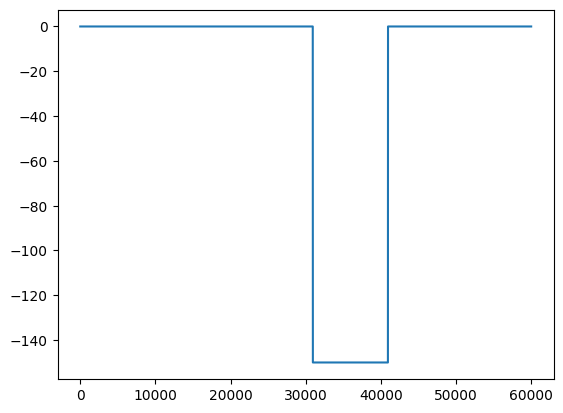

In [4]:
my_file.setSweep(sweepNumber = 0, channel = 1)
stim_line_ch2 = my_file.sweepC
#plt.plot(my_file.sweepY)
plt.plot(stim_line_ch2)

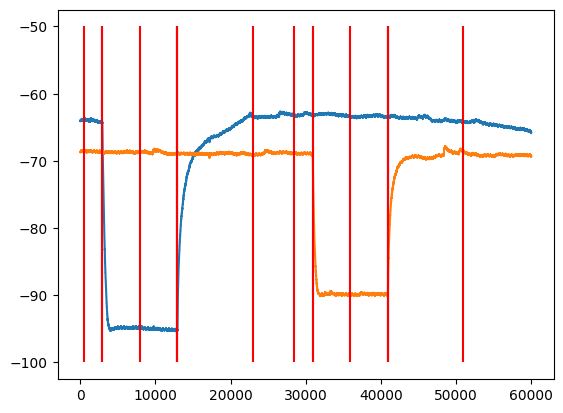

In [5]:
if channels_num >=2: 
    my_file.setSweep(sweepNumber = 0, channel = 0) #Open 1st sweep to find the stimulus
    stim_line_ch0 = my_file.sweepC #will show only the stimulus (current) where baseline == 0
    stim_step_ch0 = np.array(np.nonzero(stim_line_ch0))[0] # everything what is not 0, is the stim period
    stim_start_ch0 = stim_step_ch0[0] #stim begin
    stim_end_ch0 = stim_step_ch0[-1] #stim stop
    plt.plot(my_file.sweepY) #plot the voltage change of the sweep
    plt.vlines(stim_start_ch0, -50, -100) #stim begin line
    plt.vlines(stim_end_ch0, -50, -100) #stim stop line

if channels_num == 4: 
    my_file.setSweep(sweepNumber = 0, channel = 1) #channel index is a bog confusion. But sweepC in Ch1 returnes the stim line
    stim_line_ch2 = my_file.sweepC
    stim_step_ch2 = np.array(np.nonzero(stim_line_ch2))[0]
    stim_start_ch2 = stim_step_ch2[0]
    stim_end_ch2 = stim_step_ch2[-1]
    my_file.setSweep(sweepNumber = 0, channel = 2) #to plot the correct V change, we go correctly to Ch2
    plt.plot(my_file.sweepY)
    plt.vlines(stim_start_ch2, -50, -100)
    plt.vlines(stim_end_ch2, -50, -100)
    
else:
    print('Check number of channels')

points_needed_pre = int(0.125*sample_rate) #calculate the mean value in 125 ms at baseline
points_needed_in = int(0.25*sample_rate) #calculate the mean value in 250 ms during activity
points_needed_after = int(0.5*sample_rate) #calculate the mean value in 1 s after activity

period_prestim_ch0 = np.arange(stim_start_ch0-points_needed_pre, stim_start_ch0, 1)
period_stim_ch0 = np.arange(stim_end_ch0-points_needed_in, stim_end_ch0, 1)
period_poststim_ch0 = np.arange(stim_end_ch0, stim_end_ch0+points_needed_after, 1)

period_prestim_ch2 = np.arange(stim_start_ch2-points_needed_pre, stim_start_ch2, 1)
period_stim_ch2 = np.arange(stim_end_ch2-points_needed_in, stim_end_ch2, 1)
period_poststim_ch2 = np.arange(stim_end_ch2, stim_end_ch2+points_needed_after, 1)

plt.vlines(period_prestim_ch0[0], -50, -100, 'r')
plt.vlines(period_prestim_ch0[-1], -50, -100, 'r')
plt.vlines(period_prestim_ch2[0], -50, -100, 'r')
plt.vlines(period_prestim_ch2[-1], -50, -100, 'r')

plt.vlines(period_poststim_ch0[0], -50, -100, 'r')
plt.vlines(period_poststim_ch0[-1], -50, -100, 'r')
plt.vlines(period_poststim_ch2[0], -50, -100, 'r')
plt.vlines(period_poststim_ch2[-1], -50, -100, 'r')


plt.vlines(period_stim_ch0[0], -50, -100, 'r')
plt.vlines(period_stim_ch0[-1], -50, -100, 'r')
plt.vlines(period_stim_ch2[0], -50, -100, 'r')
plt.vlines(period_stim_ch2[-1], -50, -100, 'r')

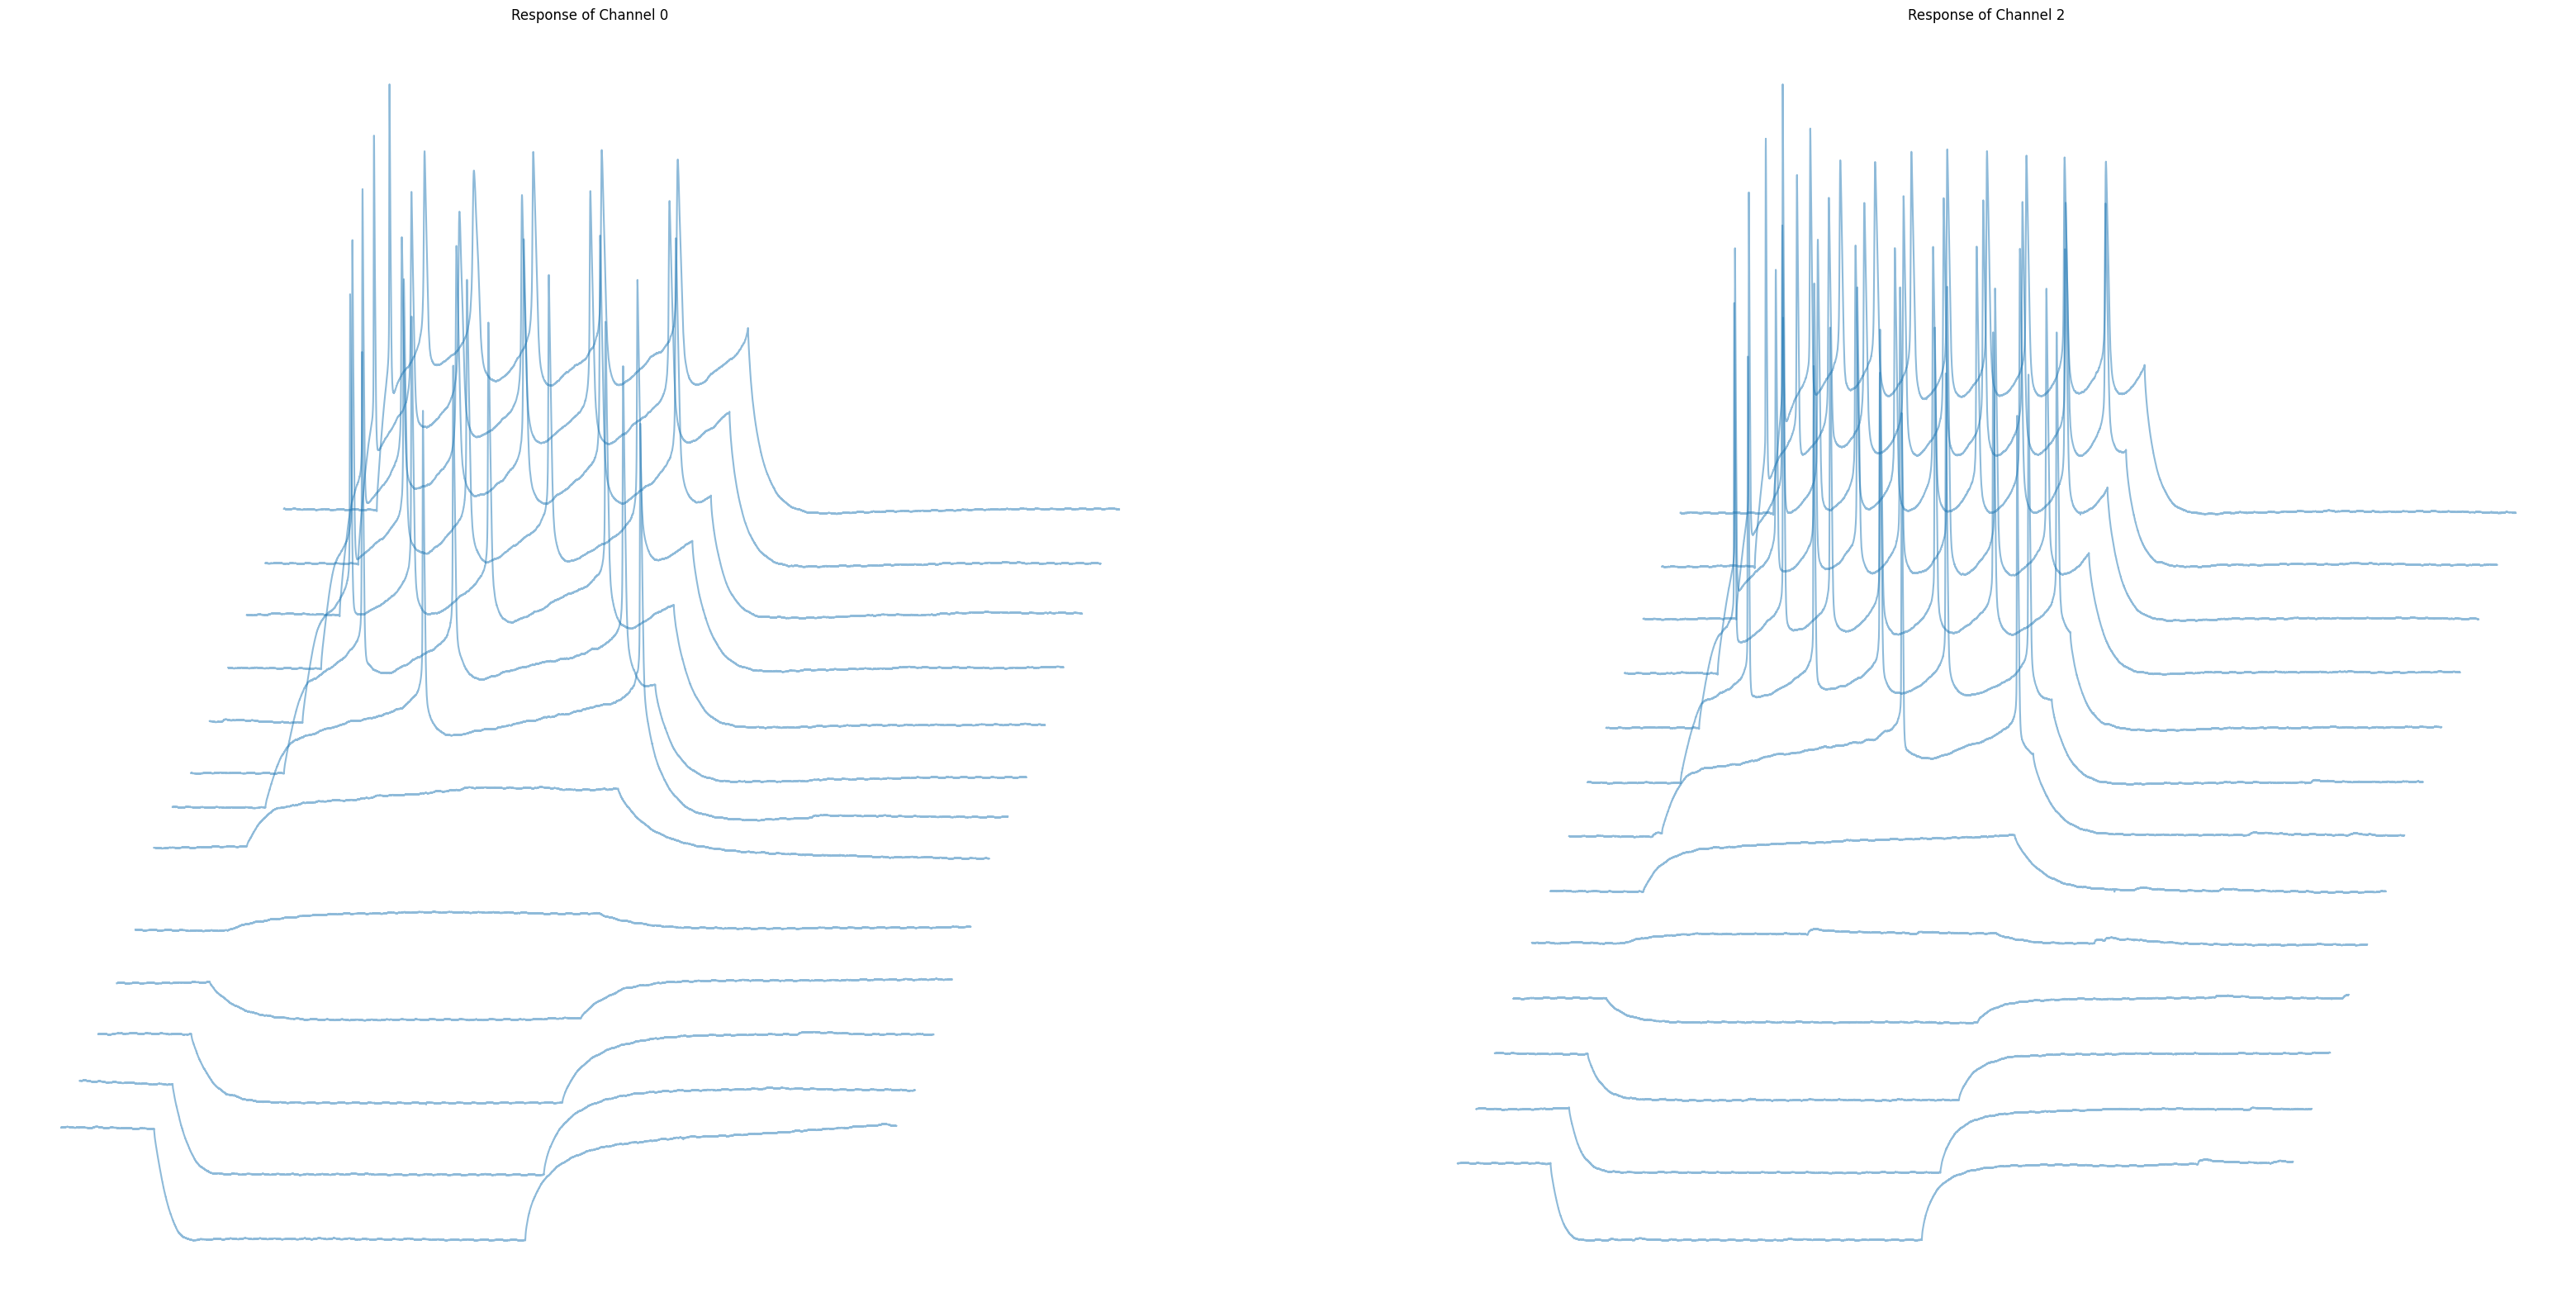

In [6]:
# Response of both cells plots

plt.figure(figsize=(40,20))

plt.subplot (1,2,1)

for my_sweepNumber in my_file.sweepList:
    my_file.setSweep(sweepNumber = my_sweepNumber, channel = 0)
    i1, i2 = period_prestim_ch0[0], period_poststim_ch0[-1]  # plot part of the sweep
    dataX = my_file.sweepX[i1:i2] + .025 * my_sweepNumber
    dataY = my_file.sweepY[i1:i2] + 15 * my_sweepNumber
    plt.plot(dataX, dataY, color='C0', alpha=.5, label=my_sweepNumber)
# matplotx.line_labels()
plt.gca().axis('off')  # hide axes to enhance floating effect
plt.title("Response of Channel 0")

plt.subplot (1,2,2)

for my_sweepNumber in my_file.sweepList:
    my_file.setSweep(sweepNumber = my_sweepNumber, channel = 2)
    i1, i2 = period_prestim_ch2[0], period_poststim_ch2[-1]  # plot part of the sweep #15000 in original for 10kHz sampling
    dataX = my_file.sweepX[i1:i2] + .025 * my_sweepNumber
    dataY = my_file.sweepY[i1:i2] + 15 * my_sweepNumber
    plt.plot(dataX, dataY, color='C0', alpha=.5, label=my_sweepNumber)
# matplotx.line_labels()
plt.gca().axis('off')  # hide axes to enhance floating effect
plt.title("Response of Channel 2")


plt.show()

In [7]:
sample_rate = int(my_file.dataRate)

#needs for correct plotting 

if sample_rate == 20000:
    # Time for PreStim and Stim for Channel 0
    start10 = 0 
    end10 = 2800    
    start11 = 6000 
    end11 = 12800 
    # Time for PreStim and Stim for Channel 2
    start20 = 28000 
    end20 = 30800 
    start21 = 34000 
    end21 = 40800 
    # Rin calculation
    Rtime_ch0 = 8000 
    Rtime_ch2 = 36000 
elif sample_rate == 10000:
    # Time for PreStim and Stim for Channel 0
    start10 = 0 
    end10 = 1400     
    start11 = 3000 
    end11 = 6400 
    # Time for PreStim and Stim for Channel 2
    start20 = 14000
    end20 = 15400
    start21 = 16600
    end21 = 20000 
    # Rin calculation
    Rtime_ch0 = 4000
    Rtime_ch2 = 18000 
else:
    print("Check the Sampling rate!")

In [7]:
# Choose channel for analysis 

my_search_ch = int(input("Please enter your #channel (0 or 2!) "))

Please enter your #channel (0 or 2!) 2


In [8]:
from scipy.signal import savgol_filter
from scipy.signal import medfilt
from scipy.signal import iirnotch, filtfilt
from scipy.signal import butter, filtfilt

def remove_50hz_noise(signal, fs, freq=50, Q=10):
    # freq — частота, которую нужно подавить (50 Гц)
    # Q — добротность фильтра: чем выше, тем уже фильтр
    b, a = iirnotch(w0=freq, Q=Q, fs=fs)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

def butter_lowpass_filter(data, cutoff, fs, order=4):
    b, a = butter(order, cutoff / (0.5 * fs), btype='low')
    return filtfilt(b, a, data)

def infl_points (file, sweep, search_ch, start, stop):
        file.setSweep(sweep, channel = search_ch)
        smooth = gaussian_filter1d(file.sweepY[start:stop], 5) # smooth
        smooth2 = savgol_filter(file.sweepY[start:stop], window_length=50, polyorder=5)
        #data = file.sweepY[start:stop]
        smooth_d2 = np.gradient(np.gradient(smooth)) # compute second derivative
        smooth_d2_filt = gaussian_filter1d(smooth_d2, 205) #
        smooth_grad = np.gradient(smooth)
        smooth_d22 = np.gradient(np.gradient(smooth2)) # compute second derivative
        smoothM = medfilt(file.sweepY[start:stop], kernel_size=2001)
        infls = np.where(np.diff(np.sign(smooth_d2_filt)))[0]# find switching points
        infls2 = np.where(np.diff(np.sign(smooth_d22)))[0]# find switching points
        ind_infls = infls + start
        ind_infls2 = infls2 + start
        return ind_infls, smooth, smooth2, ind_infls2, smooth_grad, smoothM, smooth_d2
    
def infl_pointstest (file, sweep, search_ch, start, stop):
        #file.setSweep(sweep, channel = search_ch)
        #smooth = gaussian_filter1d(file, 30) # smooth
        smooth2 = savgol_filter(file, window_length=500, polyorder=5)
        #data = file.sweepY[start:stop]
        smooth_d2 = np.gradient(np.gradient(smooth)) # compute second derivative
        smooth_d2 = gaussian_filter1d(smooth_d2, 30) #
        smooth_grad = np.gradient(smooth)
        smooth_d22 = np.gradient(np.gradient(smooth2)) # compute second derivative
        smoothM = medfilt(file, kernel_size=2001)
        infls = np.where(np.diff(np.sign(smooth_d2)))[0]# find switching points
        infls2 = np.where(np.diff(np.sign(smooth_d22)))[0]# find switching points
        ind_infls = infls + start
        ind_infls2 = infls2 + start
        return ind_infls, smooth, smooth2, ind_infls2, smooth_grad, smoothM, smooth_d2
    


def spike_begin(ind_peaks, ind_infls):
    start_ap_ind = []
    end_ap_ind = []

    for peak in ind_peaks:
        # Найти индексы точек перегиба, которые меньше пика
        infl_before_peak = [i for i in ind_infls if i < peak]

        if len(infl_before_peak) >= 2:
            # Берём ПРЕДпоследнюю перед пиком
            start_ap_ind.append(infl_before_peak[-2])
        else:
            # Если перегиб только один или ни одного — добавляем np.nan
            start_ap_ind.append(np.nan)
            
        infl_after_peak = [i for i in ind_infls if i > peak]

        if len(infl_after_peak) >= 2:
            # Берём ПРЕДпоследнюю перед пиком
            end_ap_ind.append(infl_before_peak[1])
        else:
            # Если перегиб только один или ни одного — добавляем np.nan
            end_ap_ind.append(np.nan)

    return np.array(start_ap_ind), np.array(end_ap_ind)

#my_file_filt = remove_50hz_noise(my_file.sweepY[my_stop:my_post_stop], fs=20000)
my_file.setSweep(0, channel = 0)
my_file_filt = butter_lowpass_filter(my_file.sweepY[my_stop:my_post_stop], cutoff=207, fs=20000)

plt.figure(figsize=(40,20))
plt.plot(my_file.sweepX[my_stop:my_post_stop], my_file.sweepY[my_stop:my_post_stop], label='Noisy Data', linewidth=1)
plt.plot(my_file.sweepX[my_stop:my_post_stop], my_file_filt)

#plt.ylim(-65, -55)
#my_ind_infls, my_smooth, my_smooth2, my_ind_infls2, der1, my_smoothM, der2 = infl_points(my_file_filt, my_sweep, my_search_ch, my_stop, my_post_stop)
my_ind_infls, my_smooth, my_smooth2, my_ind_infls2, der1, my_smoothM, der2 = infl_points(my_file, my_sweep, my_search_ch, my_stop, my_post_stop)
der2_filt = butter_lowpass_filter(der2, cutoff=25, fs=20000)
print(np.shape(my_smooth))
print(np.shape(my_file.sweepX[my_stop:my_post_stop]))
#my_start_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[0]
#my_end_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[1]

plt.figure(figsize=(40,20))
#The main signal
plt.plot(my_file.sweepX[my_stop:my_post_stop], my_file.sweepY[my_stop:my_post_stop], label='Noisy Data', linewidth=1)
#plt.plot(my_file.sweepX[my_stop:my_post_stop], my_smoothM, 'b')
plt.plot(my_file.sweepX[my_stop:my_post_stop], my_smooth, 'r')
plt.scatter(my_file.sweepX[my_ind_infls], my_file.sweepY[my_ind_infls])

#plt.ylim(-65, -55)
#plt.plot(my_file.sweepX[my_stop:my_post_stop], my_smooth2, 'g')
#plt.scatter(my_file.sweepX[my_ind_infls], my_file.sweepY[my_ind_infls])
plt.figure(figsize=(40,20))
plt.scatter(my_file.sweepX[my_stop:my_post_stop], der2)
plt.ylim(-0.0002, 0.0002)
der2_smooth = gaussian_filter1d(der2, 205)
plt.scatter(my_file.sweepX[my_stop:my_post_stop], der2_smooth)
plt.ylim(-0.0002, 0.0002)
#plt.scatter(my_file.sweepX[my_stop:my_post_stop], der2_filt)

plt.figure(figsize=(40,20))
plt.scatter(my_file.sweepX[my_stop:my_post_stop], der1)
plt.ylim(-0.02, 0.02)
der1_smooth = gaussian_filter1d(der1, 205)
plt.scatter(my_file.sweepX[my_stop:my_post_stop], der1_smooth)
plt.ylim(-0.02, 0.02)
#plt.plot(my_file.sweepX[my_stop:my_post_stop], my_smooth2)
#Peaks
#plt.scatter(my_file.sweepX[my_ind_peaks], my_file.sweepY[my_ind_peaks])
#Begining of the spike
#plt.scatter(my_file.sweepX[my_start_ap_ind], my_file.sweepY[my_start_ap_ind])

#plt.scatter(my_file.sweepX[my_ind_infls2], my_file.sweepY[my_ind_infls2])

NameError: name 'my_stop' is not defined

5 check peaks, how many


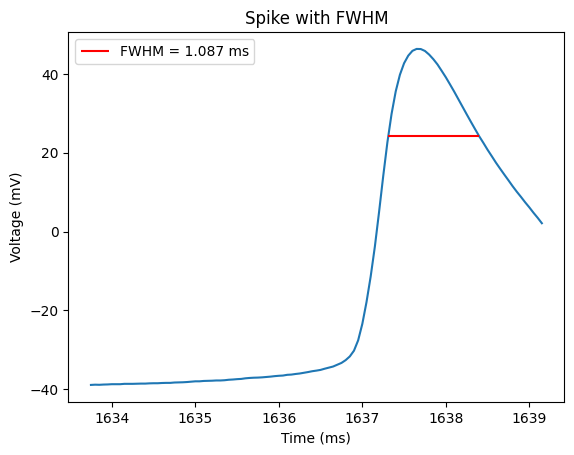


0.93 AP2/1 ration
0.99 Attenuation trend
11.29 Hz
8.97 Hz
10.49 Hz
0.79 Freq ratio
1.087 FWHM ms
90.8 Delay AP1 ms
195.716 231.633 MOhms
-68.017 Vrest mV
-70.049 cell at mV
0.983 R2 for abs Rin


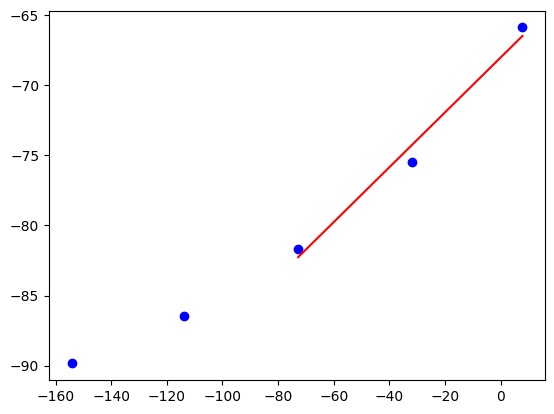

In [9]:
def channel (file, search_ch): #gives the time period in every channel to search in
    channels_num = int(file.channelCount)
    
    if channels_num >=2: 
        my_file.setSweep(sweepNumber = 0, channel = 0) #Open 1st sweep to find the stimulus
        stim_line_ch0 = my_file.sweepC #will show only the stimulus (current) where baseline == 0
        stim_step_ch0 = np.array(np.nonzero(stim_line_ch0))[0] # everything what is not 0, is the stim period
        stim_start_ch0 = stim_step_ch0[0] #stim begin
        stim_end_ch0 = stim_step_ch0[-1] #stim stop

    if channels_num == 4: 
        my_file.setSweep(sweepNumber = 0, channel = 1) #channel index is a bog confusion. But sweepC in Ch1 returnes the stim line
        stim_line_ch2 = my_file.sweepC
        stim_step_ch2 = np.array(np.nonzero(stim_line_ch2))[0]
        stim_start_ch2 = stim_step_ch2[0]
        stim_end_ch2 = stim_step_ch2[-1]
        
    points_needed_pre = int(0.125*sample_rate) #calculate the mean value in 125 ms at baseline
    points_needed_in = int(0.25*sample_rate) #calculate the mean value in 250 ms during activity
    points_needed_after = int(0.5*sample_rate) #calculate the mean value in 1 s after activity

    if search_ch == 0:
        start = stim_start_ch0
        stop = stim_end_ch0
        pre_start = stim_start_ch0-points_needed_pre
        post_stop = stim_end_ch0+points_needed_after
        within_point = stim_end_ch0-points_needed_in

    if search_ch == 2:
        start = stim_start_ch2
        stop =  stim_end_ch2
        pre_start = stim_start_ch2-points_needed_pre
        post_stop = stim_end_ch2+points_needed_after
        within_point = stim_end_ch2-points_needed_in
        
    return start, stop, pre_start, post_stop, within_point

def sweep_4Aps (file, search_ch, start, stop, v_level= -10): #choose the sweep with at least 4 spikes
    #v_level gives the threashold for spike detection
    for sweep_num in range(len(file.sweepList)):
        file.setSweep(sweep_num, channel = search_ch)
        peaks = find_peaks(file.sweepY[start:stop], height=v_level)
        #print(peaks, 'My peaks')
        if len(peaks[0])>=4:
            sweep = sweep_num #4 sweeps were detected
            break
        elif len(peaks[0])<4 and sweep_num==len(file.sweepList)-1:
            print('Sweep is not detected!')
            sweep = np.nan
    return sweep

#find the last sweep with no APs    
def sweep_1AP (my_file_abf, search_ch, start, stop, v_level= -10):
    #choose the sweep with at least 1 spikes
    for sweep_num in range(len(my_file_abf.sweepList)):
        my_file_abf.setSweep(sweep_num, channel = search_ch)
        peaks = find_peaks(my_file_abf.sweepY[start:stop], height=v_level)
        if len(peaks[0])>=1:
            sweep = sweep_num -1 #sweep with 1 spike is detected but we use the one before
            break
        elif len(peaks[0])<1 and sweep_num==len(my_file_abf.sweepList):
            #print('Sweep is not detected!')
            #sweep = None
            sweep = sweep_num #the last sweep is anyways without a single spike
    return sweep

def infl_points (file, sweep, search_ch, start, stop): #inflection points detection, 
    #number of points for smoothing in gaus filter. Less than 5 gives more than 2 inflection points in AP
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = search_ch)
        smooth = gaussian_filter1d(file.sweepY[start:stop], 5) # smooth
        smooth_d2 = np.gradient(np.gradient(smooth)) # compute second derivative
        infls = np.where(np.diff(np.sign(smooth_d2)))[0]# find switching points
        ind_infls = infls + start
        return ind_infls #else return None
    return [] 

def peak (file, sweep, search_ch, start, stop, v_level= -10): #find indexes of peaks 
    #v_level gives the threashold for spike detection
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = search_ch)
        peaks= find_peaks(file.sweepY[start:stop], height=v_level, distance=10)
        ind_peaks = peaks[0] + start
        return ind_peaks #else return None
    return [] 

def spike_begin(ind_peaks, ind_infls):
    start_ap_ind = []
    end_ap_ind = []
    
    if len(ind_peaks) == 0 or len(ind_infls) == 0:
        return start_ap_ind, end_ap_ind

    for peak in ind_peaks: 

        infl_before_peak = [i for i in ind_infls if i < peak] # Найти индексы точек перегиба, которые меньше пика

        if len(infl_before_peak) >= 2: # Берём ПРЕДпоследнюю перед пиком
            start_ap_ind.append(infl_before_peak[-2])
        else: # Если перегиб только один или ни одного — добавляем np.nan
            start_ap_ind.append(np.nan)

        infl_after_peak = [i for i in ind_infls if i > peak]

        if len(infl_after_peak) >= 2: # Берём вторую после пика пиком, в идеале дб в минимуме?
            end_ap_ind.append(infl_after_peak[1])
        else: # Если перегиб только один или ни одного — добавляем np.nan
            end_ap_ind.append(np.nan)

    return start_ap_ind, end_ap_ind

def fwhm_1st_spike (file, sweep, search_ch, ap_start, ap_end, ap_peak, sampling_rate, height = 0.5): #fwhm calculation 
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = search_ch)
        fwhm_full = scipy.signal.peak_widths(my_file.sweepY[ap_start:ap_end], #I give here info only about 1 spike (peak) !
                                            [ap_peak-ap_start], 
                                            rel_height=1 - height) #width [0] is in number of sampling points
        fwhm_full_time = np.round((fwhm_full[0][0]/sampling_rate)*1000, 3) #from sampling points to time in ms
        fwhm_indices = fwhm_full[2:4] + ap_start
        fwhm_height = fwhm_full[1][0]
        
        time = np.arange(len(file.sweepY)) / sampling_rate * 1000  # convert to ms
        plt.plot(time[ap_start:ap_end], my_file.sweepY[ap_start:ap_end])
        plt.hlines(y=fwhm_height,
                    xmin=(fwhm_indices[0] / sampling_rate) * 1000,
                    xmax=(fwhm_indices[1] / sampling_rate) * 1000,
                    color='red',
                    label=f'FWHM = {fwhm_full_time} ms'
                )
        plt.legend()
        plt.xlabel("Time (ms)")
        plt.ylabel("Voltage (mV)")
        plt.title("Spike with FWHM")
        plt.show()
        
        return fwhm_full_time, fwhm_indices, fwhm_height
    return np.nan, [], np.nan

def peak_amplitudes_ratio (file, sweep, search_ch, ap_start, ap_peak): #AP ratio calculation (Currently only 1st and 2nd)
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = search_ch)
        amplitudes = [file.sweepY[peak] - file.sweepY[start] for peak, start in zip(ap_peak, ap_start)]

        # Отношение 2/1 (если доступно)
        ampl_ratio_21 = np.round(amplitudes[1] / amplitudes[0], 2) if len(amplitudes) >= 2 else np.nan

        # Список отношений i+1 / i начиная с 2 (т.е. 3/2, 4/3 и т.д.)
        successive_ratios = [np.round(amplitudes[i+1] / amplitudes[i], 2) 
                             for i in range(1, len(amplitudes)-1)]

        # Среднее значение этих отношений
        mean_successive_ratio = np.round(np.mean(successive_ratios), 2) if successive_ratios else np.nan

        return ampl_ratio_21, successive_ratios, mean_successive_ratio
    return np.nan, [], np.nan

def frequencies (ap_peak, sampling_rate):
    if len(ap_peak) == 0:
        return np.nan, np.nan, np.nan, np.nan
    freq_12 = np.round(sampling_rate/(ap_peak[1]-ap_peak[0]), 2) #Initial firing frequency Hz
    freq_late = np.round(sampling_rate/(ap_peak[-1]-ap_peak[-2]), 2) #Late firing frequency Hz
    freq_list = [sampling_rate/(ap_peak[i+1]-ap_peak[i]) for i in range (1, len(ap_peak)-1)]
    mean_freq = np.round(statistics.mean(freq_list), 2)#Mean firing frequency Hz
    ratio_late_12 = np.round(freq_late/freq_12, 2)
    return freq_12, freq_late, mean_freq, ratio_late_12

def delay_1st_spike (start, ap_peak, sampling_rate): # TODO maybe no need
    if len(ap_peak) == 0:
        return np.nan
    time_pre1ap = np.round(((ap_peak[0]-start)/sampling_rate)*1000, 2)
    return time_pre1ap

def IV_Rin(my_file_abf, #relative values of I and V and Rin
           voltage_channel, current_channel,
           pre_start, pre_end, 
           post_start, post_end, 
           voltages_list = [], currents_list = [],
           currents_delta_list = [], voltages_delta_list = [], 
           voltage_range_ind_list = [],
           Rin_relative_list = [], Rin_abs_list = []):
    
    my_sweep = sweep_1AP(my_file_abf, voltage_channel, pre_end, post_end)

    for my_sweepNumber in range(my_sweep):
        
        my_file_abf.setSweep(sweepNumber = my_sweepNumber, channel = voltage_channel)
            
        voltage_pre_stim = np.mean(my_file_abf.sweepY[pre_start:pre_end])
        voltage_dur_stim = np.mean(my_file_abf.sweepY[post_start:post_end])
            
        voltage_delta = voltage_dur_stim - voltage_pre_stim
            
        voltages_delta_list.append(voltage_delta)
        voltages_list.append(voltage_dur_stim)

        if voltage_dur_stim >= -85 and voltage_dur_stim <= -50: #to stay only in linear part
            voltage_range_ind_list.append(my_sweepNumber)
            
        my_file_abf.setSweep(sweepNumber = my_sweepNumber, channel = current_channel)
            
        current_pre_stim = np.mean(my_file_abf.sweepY[pre_start:pre_end])
        current_dur_stim = np.mean(my_file_abf.sweepY[post_start:post_end])
                
        current_delta = current_dur_stim - current_pre_stim
        currents_delta_list.append(current_delta) 
        currents_list.append(current_dur_stim)
        
    Rin_relative_list = np.nan
 
    if (voltages_delta_list and currents_delta_list and all(i != 0 for i in currents_delta_list)): 
        Rin_relative_list = [x / y for x,y in zip(voltages_delta_list, currents_delta_list)] #all resistances
    Rin_from_range = [Rin_relative_list[x] for x in voltage_range_ind_list] #only resistances where V is in the range
    Rin_rel = np.round((np.mean(Rin_from_range))*1000, 3) # the mean relative resistance
    
    slope = np.nan
    intercept = np.nan 
    
    currents_list_ar = np.array(currents_list)
    voltages_list_ar = np.array(voltages_list)
    
    if len(currents_list_ar) >= 2 and len(voltages_list_ar) >= 2: 
        (p, residuals, rank, singular_values, rcond) = np.polyfit(currents_list_ar[voltage_range_ind_list], 
                                  voltages_list_ar[voltage_range_ind_list], 1, full = True) #linear fit
        slope, intercept = p
        x_fit = np.linspace(min(currents_list_ar[voltage_range_ind_list]), max(currents_list_ar[voltage_range_ind_list]), 100)
        y_fit = slope * x_fit + intercept
        if residuals.size > 0:
            SEE = residuals[0]
            SST = np.sum((voltages_list_ar[voltage_range_ind_list] - np.mean(voltages_list_ar[voltage_range_ind_list])) ** 2)
            R2 = np.round(1 - SEE / SST, 3) if SST != 0 else np.nan
        else:
            R2 = np.nan  # Недостаточно точек для вычисления ошибки
            
    Rin_abs = np.round(slope*1000,3) # the mean absolute resistance
    v_zero_current = np.round(intercept, 3)
    
    plt.scatter(currents_list_ar, voltages_list_ar, 
                color='blue', label='Data (IV points)')
    plt.plot(x_fit, y_fit, color='red', label=f'Linear Fit (Rin ≈ {np.round(slope, 2)} MΩ)')
                
    return currents_delta_list, voltages_delta_list, Rin_rel, currents_list, voltages_list, Rin_abs, v_zero_current, R2

def IV_values(file, sweep, voltage_channel, current_channel,
              pre_start, pre_stop, 
              in_start, in_stop):
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = voltage_channel)
        voltage_pre_stim = np.round(np.mean(file.sweepY[pre_start:pre_stop]), 3) #the cell was held at...
        file.setSweep(sweep, channel = current_channel)
        current_pre_stim = np.mean(file.sweepY[pre_start:pre_stop]) 
        current_in_stim = np.mean(file.sweepY[in_start:in_stop])
        current_injection = np.round(current_in_stim - current_pre_stim, 3) # the applied current where more than 4 APs
        return voltage_pre_stim, current_injection
    return np.nan, np.nan

#Parameters calculation

sample_rate = int(my_file.dataRate)

my_start, my_stop, my_pre_start, my_post_stop, my_within_point = channel(my_file, my_search_ch) #returns stimulation start and stop in the chosen channel

my_sweep = sweep_4Aps(my_file, my_search_ch, my_start, my_stop) # find the sweep with 4 spikes

my_ind_infls = infl_points (my_file, my_sweep, my_search_ch, my_start, my_stop) #find all inflection points

voltage_level = np.mean(my_file.sweepY[my_ind_infls]) #TODO

my_ind_peaks = peak (my_file, my_sweep, my_search_ch, my_start, my_stop) # find peaks' indexes

my_start_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[0] # Find start and end of spikes
my_end_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[1]

print (len(my_ind_peaks), 'check peaks, how many') #TODO

my_fwhm, fwhm_ind, my_fwhm_height  = fwhm_1st_spike (my_file, my_sweep, my_search_ch, # find fwhm
                                    my_start_ap_ind[0], my_end_ap_ind[0], my_ind_peaks[0], 
                                    sample_rate)

ap_ampl_ratio, my_successive_ratios, my_mean_successive_ratio = peak_amplitudes_ratio (my_file, my_sweep, my_search_ch, 
                                                                                       my_start_ap_ind, my_ind_peaks) #ampl ratio

in_freq, late_freq, mean_freq, ratio_freq_late_init = frequencies (my_ind_peaks, sample_rate) #all frequencies

#my_data_check = scipy.signal.peak_prominences(my_file.sweepY[my_start_ap_ind[0]:my_end_ap_ind[0]], my_ind_peaks[:1]-my_start_ap_ind[0])

time_pre1ap = delay_1st_spike (my_start, my_ind_peaks, sample_rate) #2st spike delay

IVRin_params = IV_Rin(my_file, my_search_ch, my_search_ch + 1, my_pre_start, my_start, my_within_point, my_stop)
my_Rin_rel, my_Rin_abs, resting_potential, m_R2 = IVRin_params[2],IVRin_params[5], IVRin_params[-2], IVRin_params[-1]

stim_params = IV_values(my_file, my_sweep, my_search_ch, my_search_ch + 1, 
                                 my_pre_start, my_start, my_within_point, my_stop)
hold_voltage, inj_current = stim_params [0], stim_params [1]

print()
print(ap_ampl_ratio, 'AP2/1 ration')
print(my_mean_successive_ratio, 'Attenuation trend')
print(in_freq, 'Hz')
print(late_freq, 'Hz')
print(mean_freq, 'Hz')
print(ratio_freq_late_init, 'Freq ratio')
print(my_fwhm, 'FWHM ms')
print(time_pre1ap, 'Delay AP1 ms')
print(my_Rin_abs, my_Rin_rel, 'MOhms')
print(resting_potential, 'Vrest mV')
print(hold_voltage, 'cell at mV')
print(m_R2, 'R2 for abs Rin')


5 check peaks, how many


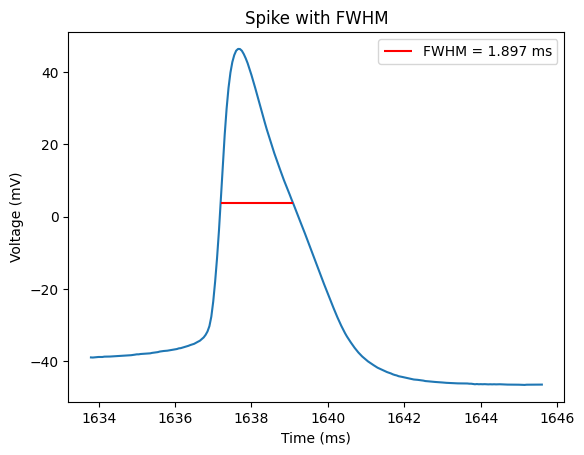


0.95 AP2/1 ration
0.99 Attenuation trend
11.29 Hz
8.97 Hz
10.49 Hz
0.79 Freq ratio
1.897 FWHM ms
90.8 Delay AP1 ms
195.716 231.633 MOhms
-68.017 Vrest mV
-70.049 cell at mV
0.983 R2 for abs Rin


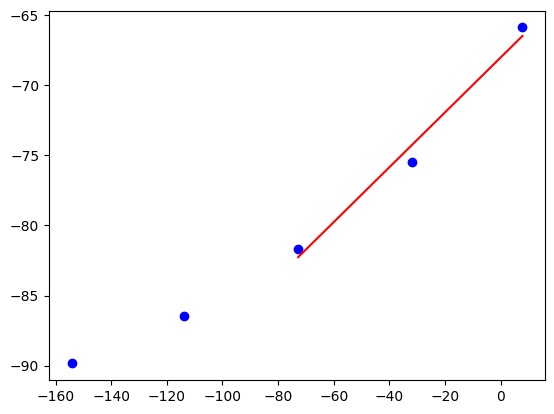

In [24]:
def channel (file, search_ch): #gives the time period in every channel to search in
    channels_num = int(file.channelCount)
    
    if channels_num >=2: 
        my_file.setSweep(sweepNumber = 0, channel = 0) #Open 1st sweep to find the stimulus
        stim_line_ch0 = my_file.sweepC #will show only the stimulus (current) where baseline == 0
        stim_step_ch0 = np.array(np.nonzero(stim_line_ch0))[0] # everything what is not 0, is the stim period
        stim_start_ch0 = stim_step_ch0[0] #stim begin
        stim_end_ch0 = stim_step_ch0[-1] #stim stop

    if channels_num == 4: 
        my_file.setSweep(sweepNumber = 0, channel = 1) #channel index is a bog confusion. But sweepC in Ch1 returnes the stim line
        stim_line_ch2 = my_file.sweepC
        stim_step_ch2 = np.array(np.nonzero(stim_line_ch2))[0]
        stim_start_ch2 = stim_step_ch2[0]
        stim_end_ch2 = stim_step_ch2[-1]
        
    points_needed_pre = int(0.125*sample_rate) #calculate the mean value in 125 ms at baseline
    points_needed_in = int(0.25*sample_rate) #calculate the mean value in 250 ms during activity
    points_needed_after = int(0.5*sample_rate) #calculate the mean value in 1 s after activity

    if search_ch == 0:
        start = stim_start_ch0
        stop = stim_end_ch0
        pre_start = stim_start_ch0-points_needed_pre
        post_stop = stim_end_ch0+points_needed_after
        within_point = stim_end_ch0-points_needed_in

    if search_ch == 2:
        start = stim_start_ch2
        stop =  stim_end_ch2
        pre_start = stim_start_ch2-points_needed_pre
        post_stop = stim_end_ch2+points_needed_after
        within_point = stim_end_ch2-points_needed_in
        
    return start, stop, pre_start, post_stop, within_point

def sweep_4Aps (file, search_ch, start, stop, v_level= -10): #choose the sweep with at least 4 spikes
    #v_level gives the threashold for spike detection
    for sweep_num in range(len(file.sweepList)):
        file.setSweep(sweep_num, channel = search_ch)
        peaks = find_peaks(file.sweepY[start:stop], height=v_level)
        #print(peaks, 'My peaks')
        if len(peaks[0])>=4:
            sweep = sweep_num #4 sweeps were detected
            break
        elif len(peaks[0])<4 and sweep_num==len(file.sweepList)-1:
            print('Sweep is not detected!')
            sweep = np.nan
    return sweep

#find the last sweep with no APs    
def sweep_1AP (my_file_abf, search_ch, start, stop, v_level= -10):
    #choose the sweep with at least 1 spikes
    for sweep_num in range(len(my_file_abf.sweepList)):
        my_file_abf.setSweep(sweep_num, channel = search_ch)
        peaks = find_peaks(my_file_abf.sweepY[start:stop], height=v_level)
        if len(peaks[0])>=1:
            sweep = sweep_num -1 #sweep with 1 spike is detected but we use the one before
            break
        elif len(peaks[0])<1 and sweep_num==len(my_file_abf.sweepList):
            #print('Sweep is not detected!')
            #sweep = None
            sweep = sweep_num #the last sweep is anyways without a single spike
    return sweep

def sweep_RB (my_file_abf, search_ch, start, stop, v_level= -10):
    sweep = 0 #sweep with RB, currentrly the 1st one, the very negative
    return sweep

def infl_points (file, sweep, search_ch, start, stop): #inflection points detection, 
    #number of points for smoothing in gaus filter. Less than 5 gives more than 2 inflection points in AP
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = search_ch)
        smooth = gaussian_filter1d(file.sweepY[start:stop], 10) # smooth
        smooth_d2 = np.gradient(np.gradient(smooth)) # compute second derivative
        infls = np.where(np.diff(np.sign(smooth_d2)))[0]# find switching points
        ind_infls = infls + start
        return ind_infls #else return None
    return [] 

def peak (file, sweep, search_ch, start, stop, v_level= -10): #find indexes of peaks 
    #v_level gives the threashold for spike detection
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = search_ch)
        peaks= find_peaks(file.sweepY[start:stop], height=v_level, distance=10)
        ind_peaks = peaks[0] + start
        return ind_peaks #else return None
    return [] 

def spike_begin(ind_peaks, ind_infls):
    start_ap_ind = []
    end_ap_ind = []
    
    if len(ind_peaks) == 0 or len(ind_infls) == 0:
        return start_ap_ind, end_ap_ind

    for peak in ind_peaks: 

        infl_before_peak = [i for i in ind_infls if i < peak] # Найти индексы точек перегиба, которые меньше пика

        if len(infl_before_peak) >= 2: # Берём ПРЕДпоследнюю перед пиком
            start_ap_ind.append(infl_before_peak[-2])
        else: # Если перегиб только один или ни одного — добавляем np.nan
            start_ap_ind.append(np.nan)

        infl_after_peak = [i for i in ind_infls if i > peak]

        if len(infl_after_peak) >= 2: # Берём вторую после пика пиком, в идеале дб в минимуме?
            end_ap_ind.append(infl_after_peak[1])
        else: # Если перегиб только один или ни одного — добавляем np.nan
            end_ap_ind.append(np.nan)

    return start_ap_ind, end_ap_ind

def fwhm_1st_spike (file, sweep, search_ch, ap_start, ap_end, ap_peak, sampling_rate, height = 0.5): #fwhm calculation 
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = search_ch)
        fwhm_full = scipy.signal.peak_widths(my_file.sweepY[ap_start:ap_end], #I give here info only about 1 spike (peak) !
                                            [ap_peak-ap_start], 
                                            rel_height=1 - height) #width [0] is in number of sampling points
        fwhm_full_time = np.round((fwhm_full[0][0]/sampling_rate)*1000, 3) #from sampling points to time in ms
        fwhm_indices = fwhm_full[2:4] + ap_start
        fwhm_height = fwhm_full[1][0]
        
        time = np.arange(len(file.sweepY)) / sampling_rate * 1000  # convert to ms
        plt.plot(time[ap_start:ap_end], my_file.sweepY[ap_start:ap_end])
        plt.hlines(y=fwhm_height,
                    xmin=(fwhm_indices[0] / sampling_rate) * 1000,
                    xmax=(fwhm_indices[1] / sampling_rate) * 1000,
                    color='red',
                    label=f'FWHM = {fwhm_full_time} ms'
                )
        plt.legend()
        plt.xlabel("Time (ms)")
        plt.ylabel("Voltage (mV)")
        plt.title("Spike with FWHM")
        plt.show()
        
        return fwhm_full_time, fwhm_indices, fwhm_height
    return np.nan, [], np.nan

def peak_amplitudes_ratio (file, sweep, search_ch, ap_start, ap_peak): #AP ratio calculation (Currently only 1st and 2nd)
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = search_ch)
        amplitudes = [file.sweepY[peak] - file.sweepY[start] for peak, start in zip(ap_peak, ap_start)]

        # Отношение 2/1 (если доступно)
        ampl_ratio_21 = np.round(amplitudes[1] / amplitudes[0], 2) if len(amplitudes) >= 2 else np.nan

        # Список отношений i+1 / i начиная с 2 (т.е. 3/2, 4/3 и т.д.)
        successive_ratios = [np.round(amplitudes[i+1] / amplitudes[i], 2) 
                             for i in range(1, len(amplitudes)-1)]

        # Среднее значение этих отношений
        mean_successive_ratio = np.round(np.mean(successive_ratios), 2) if successive_ratios else np.nan

        return ampl_ratio_21, successive_ratios, mean_successive_ratio
    return np.nan, [], np.nan

def frequencies (ap_peak, sampling_rate):
    if len(ap_peak) == 0:
        return np.nan, np.nan, np.nan, np.nan
    freq_12 = np.round(sampling_rate/(ap_peak[1]-ap_peak[0]), 2) #Initial firing frequency Hz
    freq_late = np.round(sampling_rate/(ap_peak[-1]-ap_peak[-2]), 2) #Late firing frequency Hz
    freq_list = [sampling_rate/(ap_peak[i+1]-ap_peak[i]) for i in range (1, len(ap_peak)-1)]
    mean_freq = np.round(statistics.mean(freq_list), 2)#Mean firing frequency Hz
    ratio_late_12 = np.round(freq_late/freq_12, 2)
    return freq_12, freq_late, mean_freq, ratio_late_12

def delay_1st_spike (start, ap_peak, sampling_rate): # TODO maybe no need
    if len(ap_peak) == 0:
        return np.nan
    time_pre1ap = np.round(((ap_peak[0]-start)/sampling_rate)*1000, 2)
    return time_pre1ap

def IV_Rin(my_file_abf, #relative values of I and V and Rin
           voltage_channel, current_channel,
           pre_start, pre_end, 
           post_start, post_end, 
           voltages_list = [], currents_list = [],
           currents_delta_list = [], voltages_delta_list = [], 
           voltage_range_ind_list = [],
           Rin_relative_list = [], Rin_abs_list = []):
    
    my_sweep = sweep_1AP(my_file_abf, voltage_channel, pre_end, post_end)

    for my_sweepNumber in range(my_sweep):
        
        my_file_abf.setSweep(sweepNumber = my_sweepNumber, channel = voltage_channel)
            
        voltage_pre_stim = np.mean(my_file_abf.sweepY[pre_start:pre_end])
        voltage_dur_stim = np.mean(my_file_abf.sweepY[post_start:post_end])
            
        voltage_delta = voltage_dur_stim - voltage_pre_stim
            
        voltages_delta_list.append(voltage_delta)
        voltages_list.append(voltage_dur_stim)

        if voltage_dur_stim >= -85 and voltage_dur_stim <= -50: #to stay only in linear part
            voltage_range_ind_list.append(my_sweepNumber)
            
        my_file_abf.setSweep(sweepNumber = my_sweepNumber, channel = current_channel)
            
        current_pre_stim = np.mean(my_file_abf.sweepY[pre_start:pre_end])
        current_dur_stim = np.mean(my_file_abf.sweepY[post_start:post_end])
                
        current_delta = current_dur_stim - current_pre_stim
        currents_delta_list.append(current_delta) 
        currents_list.append(current_dur_stim)
        
    Rin_relative_list = np.nan
 
    if (voltages_delta_list and currents_delta_list and all(i != 0 for i in currents_delta_list)): 
        Rin_relative_list = [x / y for x,y in zip(voltages_delta_list, currents_delta_list)] #all resistances
    Rin_from_range = [Rin_relative_list[x] for x in voltage_range_ind_list] #only resistances where V is in the range
    Rin_rel = np.round((np.mean(Rin_from_range))*1000, 3) # the mean relative resistance
    
    slope = np.nan
    intercept = np.nan 
    
    currents_list_ar = np.array(currents_list)
    voltages_list_ar = np.array(voltages_list)
    
    if len(currents_list_ar) >= 2 and len(voltages_list_ar) >= 2: 
        (p, residuals, rank, singular_values, rcond) = np.polyfit(currents_list_ar[voltage_range_ind_list], 
                                  voltages_list_ar[voltage_range_ind_list], 1, full = True) #linear fit
        slope, intercept = p
        x_fit = np.linspace(min(currents_list_ar[voltage_range_ind_list]), max(currents_list_ar[voltage_range_ind_list]), 100)
        y_fit = slope * x_fit + intercept
        if residuals.size > 0:
            SEE = residuals[0]
            SST = np.sum((voltages_list_ar[voltage_range_ind_list] - np.mean(voltages_list_ar[voltage_range_ind_list])) ** 2)
            R2 = np.round(1 - SEE / SST, 3) if SST != 0 else np.nan
        else:
            R2 = np.nan  # Недостаточно точек для вычисления ошибки
            
    Rin_abs = np.round(slope*1000,3) # the mean absolute resistance
    v_zero_current = np.round(intercept, 3)
    
    plt.scatter(currents_list_ar, voltages_list_ar, 
                color='blue', label='Data (IV points)')
    plt.plot(x_fit, y_fit, color='red', label=f'Linear Fit (Rin ≈ {np.round(slope, 2)} MΩ)')
                
    return currents_delta_list, voltages_delta_list, Rin_rel, currents_list, voltages_list, Rin_abs, v_zero_current, R2

def IV_values(file, sweep, voltage_channel, current_channel,
              pre_start, pre_stop, 
              in_start, in_stop):
    if not np.isnan(sweep):
        file.setSweep(sweep, channel = voltage_channel)
        voltage_pre_stim = np.round(np.mean(file.sweepY[pre_start:pre_stop]), 3) #the cell was held at...
        file.setSweep(sweep, channel = current_channel)
        current_pre_stim = np.mean(file.sweepY[pre_start:pre_stop]) 
        current_in_stim = np.mean(file.sweepY[in_start:in_stop])
        current_injection = np.round(current_in_stim - current_pre_stim, 3) # the applied current where more than 4 APs
        return voltage_pre_stim, current_injection
    return np.nan, np.nan

#Parameters calculation

sample_rate = int(my_file.dataRate)

my_start, my_stop, my_pre_start, my_post_stop, my_within_point = channel(my_file, my_search_ch) #returns stimulation start and stop in the chosen channel

my_sweep = sweep_4Aps(my_file, my_search_ch, my_start, my_stop) # find the sweep with 4 spikes

my_ind_infls = infl_points (my_file, my_sweep, my_search_ch, my_start, my_stop) #find all inflection points

voltage_level = np.mean(my_file.sweepY[my_ind_infls]) #TODO

my_ind_peaks = peak (my_file, my_sweep, my_search_ch, my_start, my_stop) # find peaks' indexes

my_start_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[0] # Find start and end of spikes
my_end_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[1]

print (len(my_ind_peaks), 'check peaks, how many') #TODO

my_fwhm, fwhm_ind, my_fwhm_height  = fwhm_1st_spike (my_file, my_sweep, my_search_ch, # find fwhm
                                    my_start_ap_ind[0], my_end_ap_ind[0], my_ind_peaks[0], 
                                    sample_rate)

ap_ampl_ratio, my_successive_ratios, my_mean_successive_ratio = peak_amplitudes_ratio (my_file, my_sweep, my_search_ch, 
                                                                                       my_start_ap_ind, my_ind_peaks) #ampl ratio

in_freq, late_freq, mean_freq, ratio_freq_late_init = frequencies (my_ind_peaks, sample_rate) #all frequencies

#my_data_check = scipy.signal.peak_prominences(my_file.sweepY[my_start_ap_ind[0]:my_end_ap_ind[0]], my_ind_peaks[:1]-my_start_ap_ind[0])

time_pre1ap = delay_1st_spike (my_start, my_ind_peaks, sample_rate) #2st spike delay

IVRin_params = IV_Rin(my_file, my_search_ch, my_search_ch + 1, my_pre_start, my_start, my_within_point, my_stop)
my_Rin_rel, my_Rin_abs, resting_potential, m_R2 = IVRin_params[2],IVRin_params[5], IVRin_params[-2], IVRin_params[-1]

stim_params = IV_values(my_file, my_sweep, my_search_ch, my_search_ch + 1, 
                                 my_pre_start, my_start, my_within_point, my_stop)
hold_voltage, inj_current = stim_params [0], stim_params [1]


my_sweep = sweep_RB(my_file, my_search_ch, my_start, my_stop) # find the sweep with 4 spikes
my_ind_infls = infl_points (my_file, my_sweep, my_search_ch, my_stop, my_post_stop)
my_ind_peaks = peak (my_file, my_sweep, my_search_ch, my_stop, my_post_stop)
my_start_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[0] 
my_end_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[1]

print()
print(ap_ampl_ratio, 'AP2/1 ration')
print(my_mean_successive_ratio, 'Attenuation trend')
print(in_freq, 'Hz')
print(late_freq, 'Hz')
print(mean_freq, 'Hz')
print(ratio_freq_late_init, 'Freq ratio')
print(my_fwhm, 'FWHM ms')
print(time_pre1ap, 'Delay AP1 ms')
print(my_Rin_abs, my_Rin_rel, 'MOhms')
print(resting_potential, 'Vrest mV')
print(hold_voltage, 'cell at mV')
print(m_R2, 'R2 for abs Rin')

In [137]:
my_sweep = sweep_RB(my_file, my_search_ch, my_start, my_stop) # find the sweep with 4 spikes
my_ind_infls = infl_points (my_file, my_sweep, my_search_ch, my_stop, my_post_stop)
my_ind_peaks = peak (my_file, my_sweep, my_search_ch, my_stop, my_post_stop)
my_start_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[0] 
my_end_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[1]

In [11]:
time = np.arange(len(my_file.sweepY)) / sample_rate * 1000  # convert to ms
plt.plot(time[ap_start:ap_end], file.sweepY[ap_start:ap_end])
plt.hlines(y=fwhm_height,
            xmin=(fwhm_indices[0] / sample_rate) * 1000,
            xmax=(fwhm_indices[1] / sample_rate) * 1000,
            color='red',
            label=f'FWHM = {fwhm_full_time} ms'
        )
plt.legend()
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Spike with FWHM")
plt.show()

NameError: name 'ap_start' is not defined

In [129]:
def channel (file, search_ch): #gives the time period in every channel to search in
    if search_ch == 0:
        start = period_prestim_ch0[-1]+1
        stop = period_stim_ch0[-1]
    if search_ch == 2:
        start = period_prestim_ch2[-1]+1
        stop = period_stim_ch2[-1]
    return start, stop

my_start, my_stop = channel(my_file, my_search_ch)


if my_search_ch==0:
    start_imp = int(0.1468/freq)
    time_pre1ap = (my_start_ap_ind[0]-int(0.1468/freq))*freq
if my_search_ch==2:
    start_imp = int(1.5468/freq)
    time_pre1ap = (my_start_ap_ind[0]-int(1.5468/freq))*freq
    
    

        

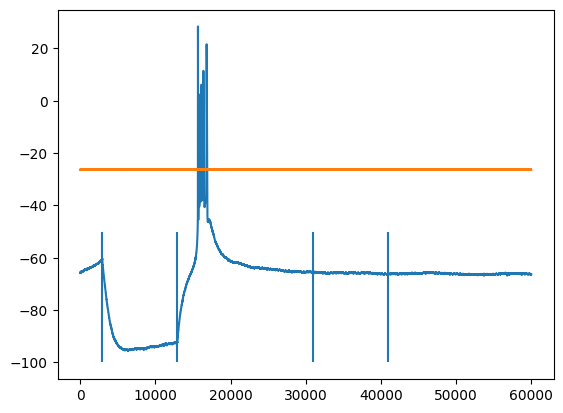

In [130]:



channels_num = int(my_file.channelCount)

if channels_num >=2: 
    my_file.setSweep(sweepNumber = 0, channel = 0) #Open 1st sweep to find the stimulus
    stim_line_ch0 = my_file.sweepC #will show only the stimulus (current) where baseline == 0
    stim_step_ch0 = np.array(np.nonzero(stim_line_ch0))[0] # everything what is not 0, is the stim period
    stim_start_ch0 = stim_step_ch0[0] #stim begin
    stim_end_ch0 = stim_step_ch0[-1] #stim stop
    plt.plot(my_file.sweepY) #plot the voltage change of the sweep
    plt.vlines(stim_start_ch0, -50, -100) #stim begin line
    plt.vlines(stim_end_ch0, -50, -100) #stim stop line

if channels_num == 4: 
    my_file.setSweep(sweepNumber = 0, channel = 1) #channel index is a bog confusion. But sweepC in Ch1 returnes the stim line
    stim_line_ch2 = my_file.sweepC
    stim_step_ch2 = np.array(np.nonzero(stim_line_ch2))[0]
    stim_start_ch2 = stim_step_ch2[0]
    stim_end_ch2 = stim_step_ch2[-1]
    my_file.setSweep(sweepNumber = 0, channel = 2) #to plot the correct V change, we go correctly to Ch2
    plt.plot(my_file.sweepY)
    plt.vlines(stim_start_ch2, -50, -100)
    plt.vlines(stim_end_ch2, -50, -100)
    
else:
    print('Check number of channels')

points_needed_pre = int(0.125*sample_rate) #calculate the mean value in 125 ms at baseline
points_needed_in = int(0.25*sample_rate) #calculate the mean value in 250 ms during activity
points_needed_after = int(0.5*sample_rate) #calculate the mean value in 1 s after activity

period_prestim_ch0 = np.arange(stim_start_ch0-points_needed_pre, stim_start_ch0, 1)
period_stim_ch0 = np.arange(stim_end_ch0-points_needed_in, stim_end_ch0, 1)
period_poststim_ch0 = np.arange(stim_end_ch0, stim_end_ch0+points_needed_after, 1)

period_prestim_ch2 = np.arange(stim_start_ch2-points_needed_pre, stim_start_ch2, 1)
period_stim_ch2 = np.arange(stim_end_ch2-points_needed_in, stim_end_ch2, 1)
period_poststim_ch2 = np.arange(stim_end_ch2, stim_end_ch2+points_needed_after, 1)

[30954 31060 31067 ... 40893 40903 40921]


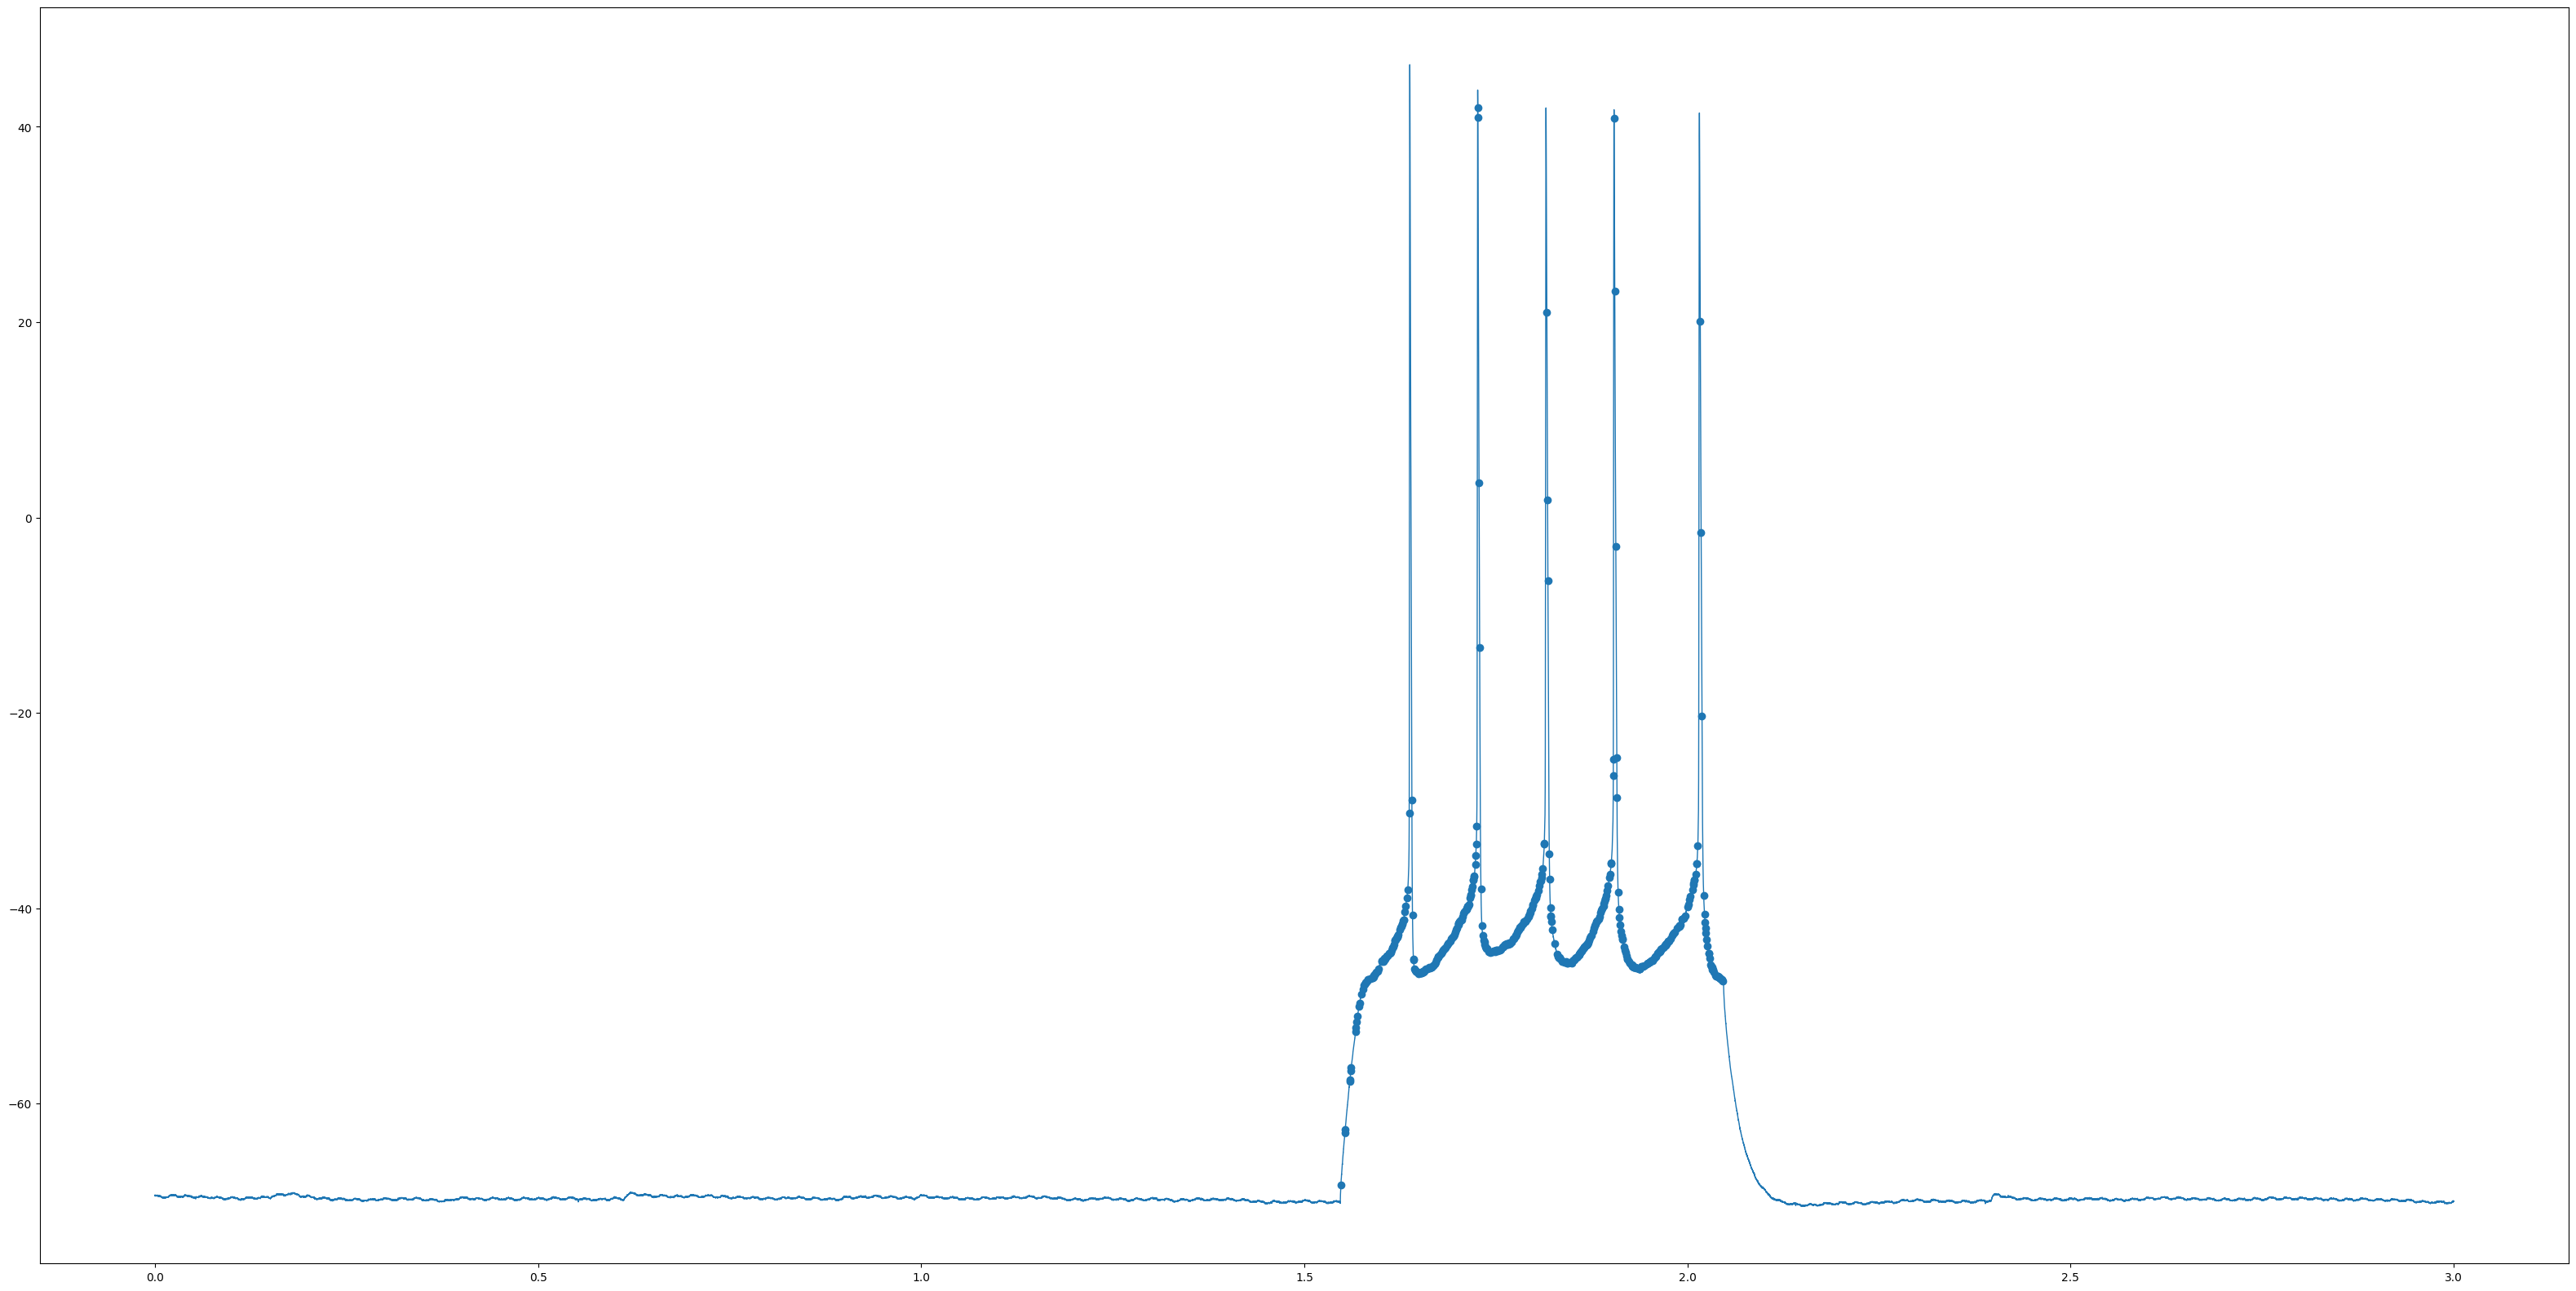

In [25]:
my_ind_infls = infl_points (my_file, my_sweep, my_search_ch, my_start, my_stop) #find all inflection points
print(my_ind_infls)

my_ind_peaks = peak (my_file, my_sweep, my_search_ch, my_start, my_stop) # find peaks' indexes

my_start_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[0] # Find start and end of spikes
my_end_ap_ind = spike_begin(my_ind_peaks, my_ind_infls)[1]

my_file.setSweep(sweepNumber = my_sweep, channel = my_search_ch)
my_file.setSweep(sweepNumber = 7, channel = 2)
plt.figure(figsize=(40,20))
#The main signal
plt.plot(my_file.sweepX, my_file.sweepY, label='Noisy Data', linewidth=1)
plt.scatter(my_file.sweepX[my_ind_infls], my_file.sweepY[my_ind_infls])
#Peaks
plt.scatter(my_file.sweepX[my_ind_peaks], my_file.sweepY[my_ind_peaks])
#Begining of the spike
plt.scatter(my_file.sweepX[my_start_ap_ind], my_file.sweepY[my_start_ap_ind])

In [68]:
#approximation to find exact position of FWHM

half_ampl = my_file.sweepY[my_start_ap_ind[0]]+ap1_ampl/2
print(half_ampl, 'half ampl')
search_up = my_file.sweepY[my_start_ap_ind[0]:my_ind_peaks[0]]
search_up_ind = []
search_down = my_file.sweepY[my_ind_peaks[0]:my_start_ap_ind[1]]
search_down_ind = []

find_up_ind = np.searchsorted(search_up, half_ampl)
#print(find_up_ind)
if my_file.sweepY[my_start_ap_ind[0]+find_up_ind]>=half_ampl:
    search_up_ind = [find_up_ind-1, find_up_ind]
if my_file.sweepY[my_start_ap_ind[0]+find_up_ind]<half_ampl:
    search_up_ind = [find_up_ind, find_up_ind+1]
    
print(search_up_ind, 'x indexes')
print(my_file.sweepY[search_up_ind+my_start_ap_ind[0]], 'Y values')

print(my_file.sweepX[search_up_ind+my_start_ap_ind[0]], 'time x for roots')
my_fit_up = np.polyfit(my_file.sweepX[search_up_ind+my_start_ap_ind[0]], my_file.sweepY[search_up_ind+my_start_ap_ind[0]], 1)
#print(my_fit)
up_p = [my_fit_up[0], my_fit_up[1]-half_ampl]
print(up_p)
my_root_up = np.roots(up_p)
print(my_root_up)


print()
print()

find_down_ind = np.searchsorted(-search_down, -half_ampl) #not the best way due to criteria for absending order 

#print(find_up_ind)
if my_file.sweepY[my_ind_peaks[0]+find_down_ind]>=half_ampl:
    search_down_ind = [find_down_ind, find_down_ind+1]
if my_file.sweepY[my_ind_peaks[0]+find_down_ind]<half_ampl:
    search_down_ind = [find_down_ind-1, find_down_ind]
    
print(search_down_ind, 'x indexes')
print(my_file.sweepY[search_down_ind+my_ind_peaks[0]], 'Y values')

print(my_file.sweepX[search_down_ind+my_ind_peaks[0]], 'time x for roots')
my_fit_down = np.polyfit(my_file.sweepX[search_down_ind+my_ind_peaks[0]], my_file.sweepY[search_down_ind+my_ind_peaks[0]], 1)
print(my_fit_down, 'coef') #coef
down_p = [my_fit_down[0], my_fit_down[1]-half_ampl]
print(down_p)
my_root_down = np.roots(down_p)
print(my_root_down)

print()
print(my_ind_peaks[0])
print(my_root_up+my_start_ap_ind[0]+search_up_ind[0])
print(my_root_down+my_ind_peaks[0]+search_down_ind[0])
my_half_total = ((my_root_down+my_ind_peaks[0]+search_down_ind[0])-(my_root_up+my_start_ap_ind[0]+search_up_ind[0]))*0.05
my_fwhm_approximated = np.round(my_half_total, 2)
my_half_total_correct = my_root_down-my_root_up
print()
print(my_half_total)
print(my_root_down-my_root_up)

0.946044921875 half ampl
[38, 39] x indexes
[-0.6104  4.8218] Y values
[0.1614 0.1615] time x for roots
[108642.57812501467, -17536.468505861747]
[0.1614]


[17, 18] x indexes
[ 1.3733 -0.824 ] Y values
[0.1627 0.1628] time x for roots
[-43945.3125   7151.2756] coef
[-43945.312500008506, 7150.329589845133]
[0.1627]

3237
[3228.1614]
[3254.1627]

[1.3001]
[0.0013]


In [16]:
#Plot the AP peak and start and 1st spike FWHM

print([my_start, my_stop])
print(my_file.sweepX[my_start:my_stop])
print([my_root_up, my_root_down])
print([my_root_up[0]*100, my_root_down[0]*100])

plt.figure(figsize=(40,20))
#The main signal
plt.plot(my_file.sweepX[my_start:my_stop], my_file.sweepY[my_start:my_stop], label='Noisy Data', linewidth=1)
#Peaks
plt.scatter(my_file.sweepX[my_ind_peaks], my_file.sweepY[my_ind_peaks])
#Begining of the spike
plt.scatter(my_file.sweepX[my_start_ap_ind], my_file.sweepY[my_start_ap_ind])


#plt.scatter(my_file.sweepX[my_end_ap_ind[0]], my_file.sweepY[my_end_ap_ind[0]])
fwhm_Y_1 = my_root_up*my_fit_up[0]+my_fit_up[1]
fwhm_Y_2 = my_root_down*my_fit_down[0]+my_fit_down[1]
plt.plot([my_root_up[0], my_root_down[0]], [fwhm_Y_1, fwhm_Y_2],  linewidth=1)

# plt.scatter(my_file.sweepX[int(my_fwhm_full[2])+my_start_ap_ind[0]], my_file.sweepY[int(my_fwhm_full[2])+my_start_ap_ind[0]])
# plt.scatter(my_file.sweepX[int(my_fwhm_full[3])+my_start_ap_ind[0]], my_file.sweepY[int(my_fwhm_full[3])+my_start_ap_ind[0]])

# plt.scatter(my_file.sweepX[my_start_ap_ind[0]+search_up_ind], my_file.sweepY[my_start_ap_ind[0]+search_up_ind])
# plt.scatter(my_file.sweepX[my_ind_peaks[0]+search_down_ind], my_file.sweepY[my_ind_peaks[0]+search_down_ind])
#plt.plot(my_file.sweepX[my_start:my_stop], smooth, label='Smoothed Data')
#plt.plot(abf.sweepX[1400:7000], smooth_d2 / np.max(smooth_d2), label='Second Derivative (scaled)')
#for i, infl in enumerate(infls, 1):
 #   plt.axvline((infl + start_ch0)*freq, color='k', label=f'Inflection Point {i}')
#plt.legend(bbox_to_anchor=(1.55, 1.0))

[30937, 40936]
[1.5469 1.5469 1.547  ... 2.0467 2.0467 2.0468]


NameError: name 'my_root_up' is not defined

In [ ]:
my_name = my_file.abfID
my_half_ampl = np.round(half_ampl, 2)
col1 = 'Name'
col2 = 'AP2/AP1 amplitude ratio'
col3 = 'Initial Frequency, Hz'
col4 = 'Late Frewuency, Hz'
col5 = 'Mean Frequency, Hz'
col6 = 'FWHM approximation, ms'
col7 = 'Voltage level'
col8 = 'Time before 1st AP'
col9 = 'FWHM built-in peak analysis, ms'
col10 = 'FWHM level'
col11 = 'Sweep number'
col12 = 'Analysed channel'


my_data = pandas.DataFrame({col1:my_name, 
                        col2:ap_ampl_ratio, 
                        col3:in_freq,
                        col4:late_freq, 
                        col5:mean_freq,
                        col6:my_fwhm_approximated,
                        col7:voltage_level,
                        col8:time_pre1ap,
                        col9:my_fwhm,
                        col10:my_half_ampl,
                        col11:my_sweep,
                        col12:my_search_ch})

    
my_data.to_excel(r'C:\Users\user\Documents\IMBIT\Master\cell_properties.xlsx', sheet_name='All data', index=False)